In [2]:
from Kea.utils import plotting
import numpy as np
import matplotlib as mpl
plotting.modify_rc()
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable

import scipy

c = plotting.COLOR_CYCLE_6

L = 5.*np.pi
_N = 256

from sympy import *

In [3]:
k = symbols('k', real=True)
s = symbols('sigma', real=True, positive=True)
xi = symbols('xi', real=True, positive=True)
D = symbols('D', integer=True, positive=True)
a = symbols('alpha', real=True, positive=True)
kr = symbols('k_r', real=True, positive=True)

Ek = k**(-a)
display(Ek)
Hk = 2 * xi * (k/kr)**2 * exp(-(k/kr)**2)
display(Hk)

S_D = symbols('S_D', positive=True, real=True)
S_D = 2 * pi**(D/2) / gamma(D/2)
kfac = k**(D-1)

k**(-alpha)

2*k**2*xi*exp(-k**2/k_r**2)/k_r**2

In [4]:
integrand1 = S_D * kfac * Abs(Hk)**2
integral1 = integrate(integrand1, (k, -oo, oo))
display(integral1.simplify())
display(integral1.subs({D: 3}))

-2**(-D/2 - 2)*pi**(D/2)*D*k_r**D*xi**2*((-1)**D - 1)*(D + 2)

15*sqrt(2)*pi**(3/2)*k_r**3*xi**2/8

In [5]:
diff_f = diff(integrand1, k)
display(diff_f)
critical_points1 = solve(diff_f, k)
display(critical_points1[1])

-32*pi**(D/2)*k**5*k**(D - 1)*xi**2*exp(-2*k**2/k_r**2)/(k_r**6*gamma(D/2)) + 8*pi**(D/2)*k**3*k**(D - 1)*xi**2*(D - 1)*exp(-2*k**2/k_r**2)/(k_r**4*gamma(D/2)) + 32*pi**(D/2)*k**3*k**(D - 1)*xi**2*exp(-2*k**2/k_r**2)/(k_r**4*gamma(D/2))

-k_r*sqrt(D + 3)/2

In [6]:
prefac = S_D * kfac * (2 * xi * (k/kr)**2)**2
integrand2 = Abs(exp(-(k/kr)**2))**2
integral2 = prefac.subs({k: kr}) * integrate(integrand2, (k, -oo, oo))
display(integral2.simplify())
display(integral2.subs({D: 3}))

4*sqrt(2)*pi**(D/2 + 1/2)*k_r**D*xi**2/gamma(D/2)

8*sqrt(2)*pi**(3/2)*k_r**3*xi**2

In [7]:
diff_f = diff(exp(-k**2 * s**2), k)
display(diff_f)
critical_points2 = solve(diff_f, k)
display(critical_points2)

-2*k*sigma**2*exp(-k**2*sigma**2)

[0]

Piecewise((-2**(alpha/2)*gamma(D/2 - alpha/2 + 2)/(((-1)**D - 1)*gamma(D/2 + 2)), D - alpha > -4), (-2**(D/2 + 3)*k_r**(-D + alpha - 4)*Integral(k**(D - alpha + 3)*exp(-2*k**2/k_r**2), (k, 0, oo))/(((-1)**D - 1)*gamma(D/2 + 2)), True))

Piecewise((2**(-D/2 + alpha/2 - 5/2)*gamma(D/2 - alpha/2 + 2)/sqrt(pi), D - alpha > -4), (sqrt(2)*k_r**(-D + alpha - 4)*Integral(k**(D - alpha + 3)*exp(-2*k**2/k_r**2), (k, 0, oo))/sqrt(pi), True))

AttributeError: 'ComplexInfinity' object has no attribute 'real'

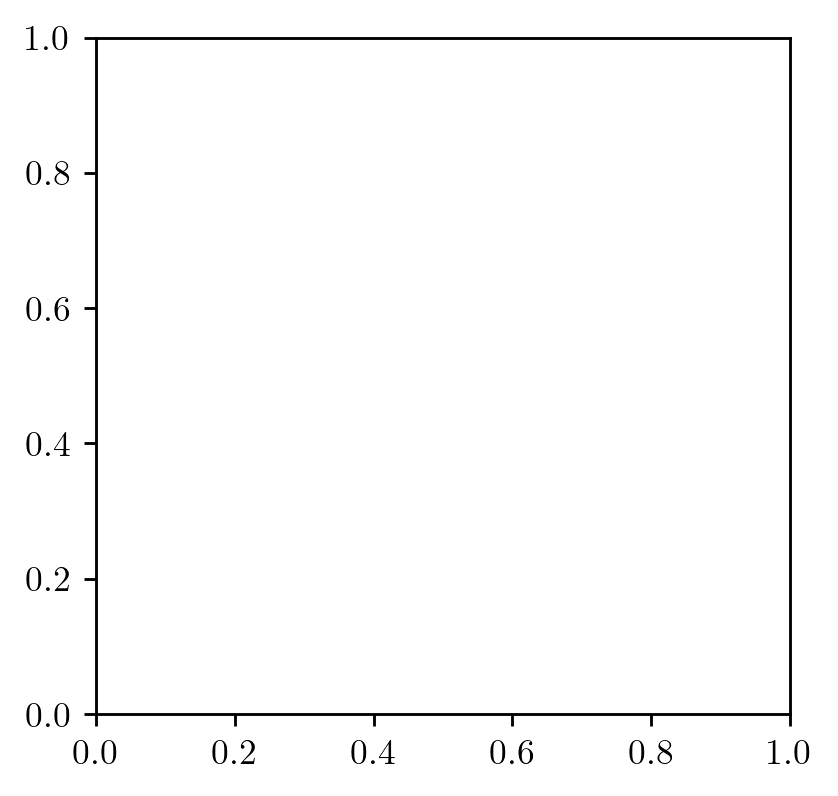

In [11]:
var_num = integrate(S_D * kfac * Ek * Abs(Hk)**2, (k, 0, oo))

var1_denom1 = integral1.simplify()
var11 = var_num / var1_denom1
var21 = Ek.subs({k: kr})
bias1 = var11 / var21
display(bias1.simplify())

var1_denom2 = integral2.simplify()
var12 = var_num / var1_denom2
var22 = Ek.subs({k: kr})
bias2 = var12 / var22
display(bias2.simplify())

fig, ax = plt.subplots(1, 1, figsize=(3.5, 3.5), dpi=256)

for i, _D in enumerate([1, 2, 3]):
    amin, amax = _D, _D + 2
    for j, _a in enumerate(np.linspace(amin, amax, 100)):
        bb = bias1.subs({D: _D, a: _a})
        ax.scatter((_a-_D)/2., bb.evalf(), marker='o', s=5., color=c[i], zorder=2, linewidth=0.2, edgecolor='black')

        bb2 = bias2.subs({D: _D, a: _a})
        ax.scatter((_a-_D)/2., bb2.evalf(), marker='X', s=5., color=c[i], zorder=2, linewidth=0.2, edgecolor='black')

ax.scatter([], [], marker='o', s=5., color=c[0], zorder=2, linewidth=0.2, edgecolor='black', label='2D Method 1.')
ax.scatter([], [], marker='o', s=5., color=c[1], zorder=2, linewidth=0.2, edgecolor='black', label='3D Method 1.')

ax.scatter([], [], marker='X', s=5., color=c[0], zorder=2, linewidth=0.2, edgecolor='black', label='2D Method 2.')
ax.scatter([], [], marker='X', s=5., color=c[1], zorder=2, linewidth=0.2, edgecolor='black', label='3D Method 2.')

ax.legend(fancybox=False, frameon=True)

ax.yaxis.set_ticks_position('both')
ax.xaxis.set_ticks_position('both')
ax.tick_params(axis='y', direction='in')
ax.tick_params(axis='y', direction='in', which='minor')
ax.tick_params(axis='x', direction='in')
ax.tick_params(axis='x', direction='in', which='minor')
ax.grid(linestyle=':', alpha=0.3, linewidth=0.5, color='gray')

ax.set_ylabel('Analytical Bias')
ax.set_xlabel('Hurst Parameter, $H$')

ax.set_yscale('log')


In [ ]:
f = S_D * kfac * Abs(Hk)**2
display(maximum(f.subs({D: 2}), k))
diff_f = diff(f, k)
display(diff_f)
critical_points = solve(diff_f, k)
for point in critical_points:
    if point == 0:
        continue
    display(point.subs(kr, 1/(sqrt(2*pi**2)*s)))
    display(f.subs(k, point))
kmax = critical_points[-1]

25*sqrt(5)*pi*k_r*xi**2*exp(-5/2)/4

-32*pi**(D/2)*k**5*k**(D - 1)*xi**2*exp(-2*k**2/k_r**2)/(k_r**6*gamma(D/2)) + 8*pi**(D/2)*k**3*k**(D - 1)*xi**2*(D - 1)*exp(-2*k**2/k_r**2)/(k_r**4*gamma(D/2)) + 32*pi**(D/2)*k**3*k**(D - 1)*xi**2*exp(-2*k**2/k_r**2)/(k_r**4*gamma(D/2))

-sqrt(2)*sqrt(D + 3)/(4*pi*sigma)

pi**(D/2)*xi**2*(-k_r*sqrt(D + 3)/2)**(D - 1)*(D + 3)**2*exp(-D/2 - 3/2)/(2*gamma(D/2))

sqrt(2)*sqrt(D + 3)/(4*pi*sigma)

pi**(D/2)*xi**2*(k_r*sqrt(D + 3)/2)**(D - 1)*(D + 3)**2*exp(-D/2 - 3/2)/(2*gamma(D/2))